In [38]:
from pathlib import Path
import csv
import pandas as pd
import matplotlib.pyplot as plt

root = Path("../captures")
csv_files = {
    "no validation": root / "none_gpu.csv",
    "AABB clipping": root / "aabbclamp.csv",
    "Variance clipping": root / "variance_gpu.csv",
    "k-DOP": root / "kdop_gpu.csv",
}


In [39]:

def load_zone_times_ms(path, zone_name):
    times_ms = []

    with open(path, "r", encoding="utf-16") as csv_file:
        rows = csv.DictReader(csv_file)

        for row in rows:
            if row["name"].strip().casefold() == zone_name.casefold():
                duration_ns = float(row["GPU execution time"])
                times_ms.append(duration_ns / 1_000_000)

    if not times_ms:
        raise ValueError(f"No {zone_name!r} rows found in {path}")

    return times_ms


taa_times = {
    method: load_zone_times_ms(path, "TAA pass")
    for method, path in csv_files.items()
}

taa_df = pd.concat(
    [pd.DataFrame({"method": method, "time_ms": times}) for method, times in taa_times.items()],
    ignore_index=True,
)
taa_df.head()

,method,time_ms
0,no validation,0.050176
1,no validation,0.069632
2,no validation,0.069632
3,no validation,0.069632
4,no validation,0.070656


In [40]:
summary = (
    taa_df.groupby("method")["time_ms"]
    .agg(["count", "median", "mean"])
    .sort_values(by="median").round(5)
    )

summary

,count,median,mean
method,,,
no validation,26553,0.14746,0.31991
AABB clipping,27248,0.25190,0.31888
Variance clipping,30297,0.36966,0.45308
k-DOP,21009,0.76902,0.85473


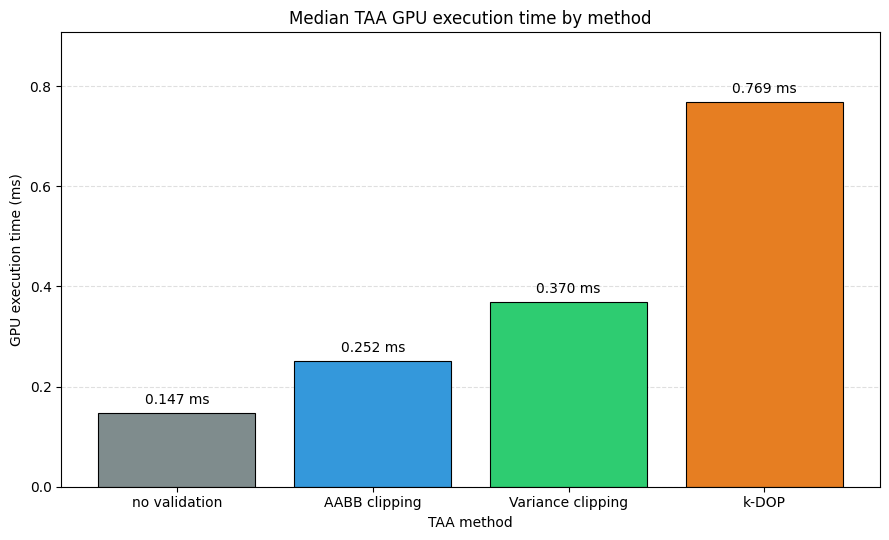

In [42]:
methods = list(taa_times)
median_times_ms = [statistics.median(taa_times[method]) for method in methods]

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(
    methods,
    median_times_ms,
    color=["#7f8c8d", "#3498db", "#2ecc71", "#e67e22"],
    edgecolor="black",
    linewidth=0.8,
)

ax.set_title("Median TAA GPU execution time by method")
ax.set_xlabel("TAA method")
ax.set_ylabel("GPU execution time (ms)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.bar_label(bars, labels=[f"{value:.3f} ms" for value in median_times_ms], padding=4)
ax.set_ylim(0, max(median_times_ms) * 1.18)

fig.tight_layout()
fig.savefig("taa_gpu_time_by_method.png", dpi=300, bbox_inches="tight")
plt.show()